# Lorenz-96: LETKF

## 1. Overview

This tutorial applies the local ensemble transform Kalman filter (LETKF) to
the 40-variable Lorenz-96 model. Localization allows a small ensemble
($m = 12$, fewer members than the ETKF needs on this problem) to remain
stable. It follows `docs/contributing/notebook_spec.md`; the paired CLI script is
`examples/scripts/l96_letkf.py`.

## 2. Model

The Lorenz-96 model describes $J$ variables on a periodic ring,

$$
\dot{x}_j = (x_{j+1} - x_{j-2})\, x_{j-1} - x_j + F,
\qquad j = 1, \dots, J \ (\text{indices mod } J),
$$

with $J = 40$ and forcing $F = 8$, a standard chaotic configuration
(`da.l96.lorenz96`). The forecast map $M$ integrates with fourth-order
Runge-Kutta (`da.scheme.rk4`), time step $\delta t$, over one assimilation
window of $n_{\mathrm{obs}}$ steps ($\Delta t = n_{\mathrm{obs}}\,\delta t$).

## 3. Observation

The full state is observed with additive Gaussian noise every assimilation
window:

$$
y_{n} = H x_{n} + \varepsilon_{n}, \qquad H = I_J, \qquad
\varepsilon_{n} \sim N(0, R), \quad R = r_0^2 I_J,
$$

so the observation-noise scale is
$\sigma_{\mathrm{obs}} = \sqrt{\mathrm{tr}(R)/N_{y}} = r_0$.

## 4. DA method

The **LETKF** performs, for every state component $j$, an ETKF analysis in
ensemble space using only nearby observations.

**Forecast step:** $x_{n}^{f,(i)} = M(x_{n-1}^{a,(i)})$ for each member.

**Analysis step (per component $j$):** the ETKF update

$$
\tilde{P}_{j} = \big[(m-1) I + (H A^{f})^{\top} \tilde{R}_{j}^{-1}
(H A^{f})\big]^{-1}, \qquad
\bar{x}_{j}^{a} = \bar{x}_{j}^{f} + \big(A^{f} \tilde{P}_{j} (H A^{f})^{\top}
\tilde{R}_{j}^{-1} (y - H \bar{x}^{f})\big)_{j},
$$

uses the localized observation precision
$\tilde{R}_{j}^{-1} = R^{-1} \circ \rho(d_{j} / c)$, where $d_{j}$ is the
ring distance from component $j$ to each observation site, $c$ is the
localization radius, and $\rho$ is the Gaspari-Cohn compactly supported
correlation function. Anomalies are inflated multiplicatively,
$A \to \alpha A$.

## 5. Parameters

| Parameter | Symbol | Value |
| --- | --- | --- |
| dimension / forcing | $J$, $F$ | 40, 8 |
| integration step | $\delta t$ | 0.01 |
| steps per window | $n_{\mathrm{obs}}$ | 5 |
| assimilation cycles | | 200 |
| truth spin-up steps | | 500 |
| observation noise variance | $r_0^2$ | 1.0 |
| ensemble size | $m$ | 12 |
| multiplicative inflation | $\alpha$ | 1.05 |
| localization radius | $c$ | 6.0 |
| initial ensemble | | attractor sample |
| random seed | | 11 |

The script exposes `--cycles`, `--dimension`, `--ensemble-size`,
`--localization-radius`, `--obs-noise-variance`, `--inflation`, `--dt`,
`--obs-interval`, and `--seed`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from da.l96 import lorenz96
from da.scheme import rk4
from da.letkf import LETKF

def l96_step(x, dt, forcing=8.0):
    return rk4(lorenz96, 0.0, np.asarray(x), (forcing,), dt)


def advance(x, dt, n_steps):
    x = np.asarray(x, dtype=float).copy()
    for _ in range(n_steps):
        x = l96_step(x, dt)
    return x


def rmse(x, truth):
    return float(np.sqrt(np.mean((np.asarray(x) - np.asarray(truth)) ** 2)))


def attractor_ensemble(rng, base, size, spinup=2000, interval=25, pool=1000):
    """Climatological sample from the attractor (cf. examples/scripts/_common.py)."""
    x = advance(base, dt, spinup)
    members = np.empty((pool, np.size(base)))
    for i in range(pool):
        x = advance(x, dt, interval)
        members[i] = x
    return members[rng.choice(pool, size=size, replace=False)]

J, dt, obs_interval, cycles, seed = 40, 0.01, 5, 200, 11
m, alpha, c = 12, 1.05, 6.0
H = np.eye(J)
R = np.eye(J)

## 6. Truth and observations

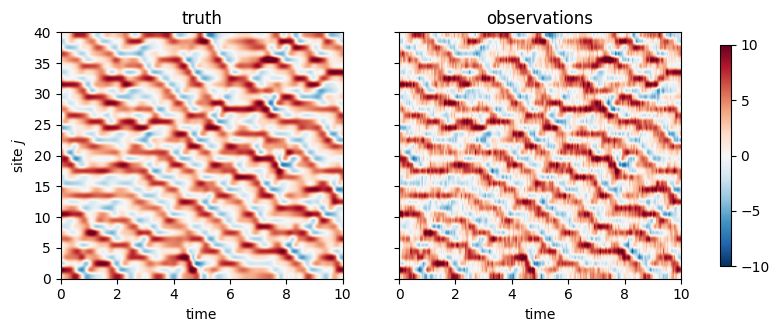

In [2]:
rng = np.random.default_rng(seed)
x = 8.0 * np.ones(J)
x[0] += 0.01
x = advance(x, dt, 500)  # spin-up onto the attractor
truth = [x.copy()]
obs = [H @ x + rng.multivariate_normal(np.zeros(J), R)]
for _ in range(cycles):
    x = advance(x, dt, obs_interval)
    truth.append(x.copy())
    obs.append(H @ x + rng.multivariate_normal(np.zeros(J), R))
truth, obs = np.asarray(truth), np.asarray(obs)
t = np.arange(cycles + 1) * dt * obs_interval

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, field, title in ((axes[0], truth, "truth"), (axes[1], obs, "observations")):
    im = ax.imshow(field.T, aspect="auto", origin="lower", cmap="RdBu_r",
                   vmin=-10, vmax=10, extent=[t[0], t[-1], 0, J])
    ax.set_title(title)
    ax.set_xlabel("time")
axes[0].set_ylabel("site $j$")
fig.colorbar(im, ax=axes, shrink=0.9)

## 7. Assimilation results

In [3]:
base = 8.0 * np.ones(J)
base[0] += 0.01
X0 = attractor_ensemble(rng, base, m)
filt = LETKF(l96_step, H, R, alpha=alpha, c=c)
filt.initialize(X0)

means = [filt.X.mean(axis=0)]
rmses = [rmse(means[0], truth[0])]
for k in range(1, cycles + 1):
    for _ in range(obs_interval):
        filt.forecast(dt)
    filt.update(obs[k])
    means.append(filt.X.mean(axis=0))
    rmses.append(rmse(means[-1], truth[k]))
means, rmses = np.asarray(means), np.asarray(rmses)

Text(0, 0.5, 'site $j$')

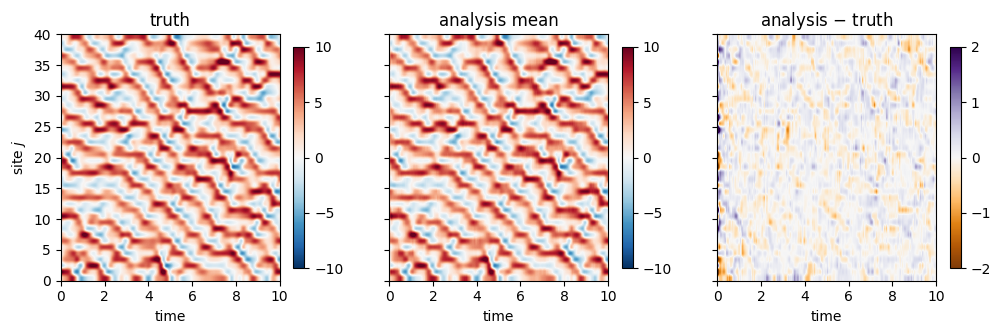

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, field, title, (vmin, vmax), cmap in (
    (axes[0], truth, "truth", (-10, 10), "RdBu_r"),
    (axes[1], means, "analysis mean", (-10, 10), "RdBu_r"),
    (axes[2], means - truth, "analysis $-$ truth", (-2, 2), "PuOr"),
):
    im = ax.imshow(field.T, aspect="auto", origin="lower", cmap=cmap,
                   vmin=vmin, vmax=vmax, extent=[t[0], t[-1], 0, J])
    ax.set_title(title)
    ax.set_xlabel("time")
    fig.colorbar(im, ax=ax, shrink=0.9)
axes[0].set_ylabel("site $j$")

## 8. RMSE

observation noise scale: 1.000
mean RMSE (2nd half): 0.240


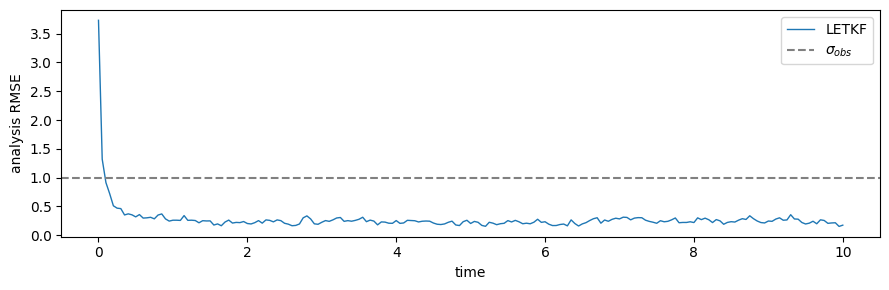

In [5]:
sigma_obs = np.sqrt(np.trace(R) / R.shape[0])
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t, rmses, color="tab:blue", lw=1, label="LETKF")
ax.axhline(sigma_obs, color="gray", ls="--", label=r"$\sigma_{obs}$")
ax.set_xlabel("time")
ax.set_ylabel("analysis RMSE")
ax.legend()
fig.tight_layout()

half = cycles // 2
print(f"observation noise scale: {sigma_obs:.3f}")
print(f"mean RMSE (2nd half): {rmses[half:].mean():.3f}")

## 9. Summary

The LETKF with only $m = 12$ members reaches a mean analysis RMSE near
$0.24$, far below $\sigma_{\mathrm{obs}} = 1$ and comparable to the
$m = 20$ ETKF. Localization suppresses spurious long-range covariances of
the small ensemble, so each component is updated only by informative nearby
observations — the standard mechanism that makes ensemble DA affordable in
high dimension.